#### **Exercise 1**

There are outliers in the `Age` column of `sample-data-with-outliers.csv`. 1) Create a boxplot for `Age` 2) Use a statistical method for identifying outliers in `Age` 3) Create a version of the data where outliers are **removed** from `Age` and make a boxplot for `Age` 3) Create a version of the data where outliers from `Age` are **imputed** and make a boxplot for `Age`.

In [1]:
import pandas as pd
data = pd.read_csv('https://ist707.s3.us-east-2.amazonaws.com/data/sample-data-with-outliers.csv')
data.head()

,Age,Income,Purchase
0,76,75071,1
1,88,62405,0
2,82,61914,1
3,81,66843,1
4,62,30492,0


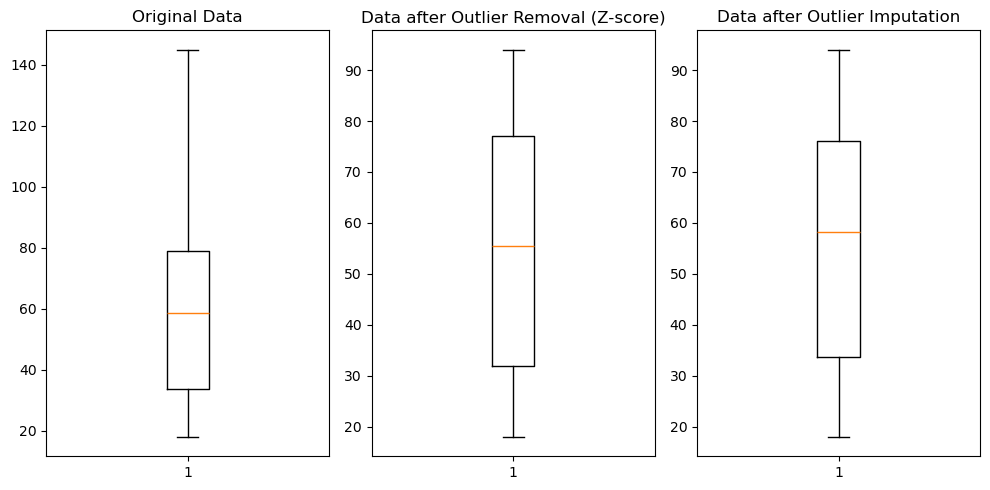

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Original DataFrame
original_df = data.copy()

# Detecting outliers using Z-score
# Using the Age variable
data['Z_Score'] = zscore(data['Age'])
outliers_z_score = data[np.abs(data['Z_Score']) > 2]

# Handling outliers: Removal
df_no_outliers_z = data[np.abs(data['Z_Score']) <= 2]

# Handling outliers: Imputation (Replace with Median)
df_imputed = data.copy()
df_imputed['Age'] = df_imputed['Age'].astype(float)
df_imputed.loc[data.index.isin(outliers_z_score.index), 'Age'] = data['Age'].median()


# Create Subplots
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].boxplot(original_df['Age'])
axs[0].set_title('Original Data')

axs[1].boxplot(df_no_outliers_z['Age'])
axs[1].set_title('Data after Outlier Removal (Z-score)')

axs[2].boxplot(df_imputed['Age'])
axs[2].set_title('Data after Outlier Imputation')

plt.tight_layout()
plt.show()

#### **Exercise 2**

In the following, I've created a sample dataset with an exponential feature and a normal feature. Run the classifer and examine the results. How do your results change:

1.  If you scale the exponential feature using a `StandardScaler`
2.  If you scale the exponential feature using a log transform

Original
Logistic Regression Test Accuracy: 0.72


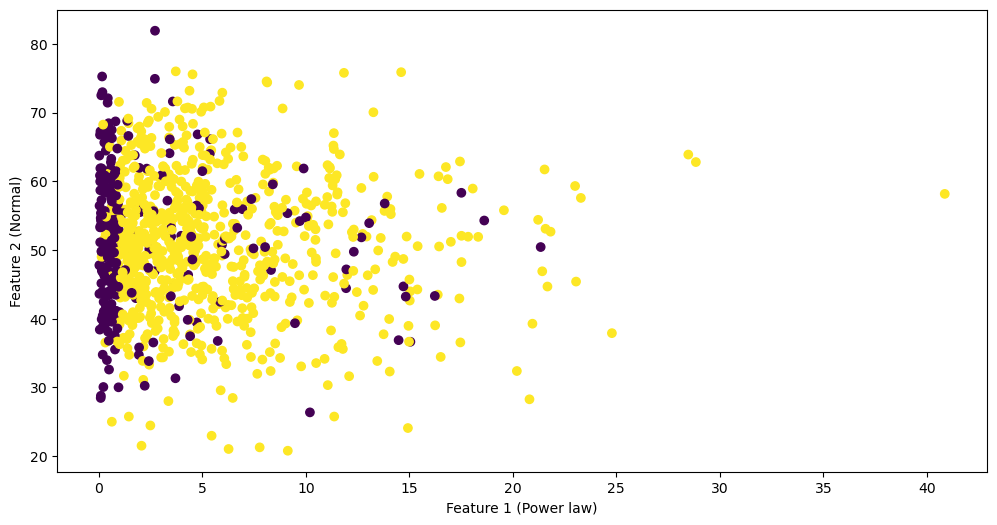

Standard Scalar
[[-0.5177219   0.07972695]
 [ 2.09626152 -1.45101619]
 [ 0.35414755  0.28459236]
 ...
 [-0.84913121 -0.13752259]
 [ 2.08635356 -0.53437626]
 [-0.39289681 -0.80057267]]
Logistic Regression Test Accuracy: 0.72


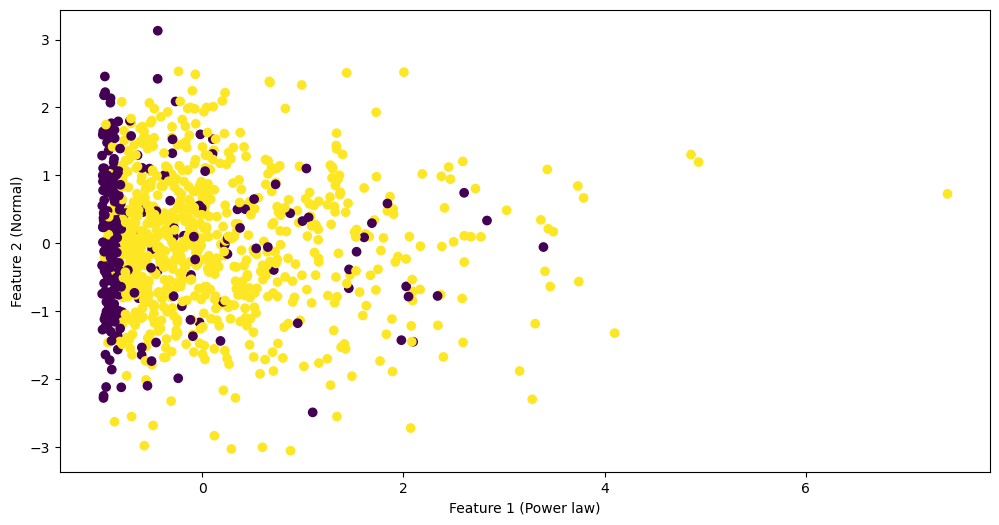

Log Normalized
[[ 0.85285686  3.94694623]
 [ 2.71141833  3.60131947]
 [ 1.88460122  3.98531024]
 ...
 [-0.30699777  3.90458808]
 [ 2.70821374  3.82225097]
 [ 1.08282332  3.76296113]]
Logistic Regression Test Accuracy: 0.91


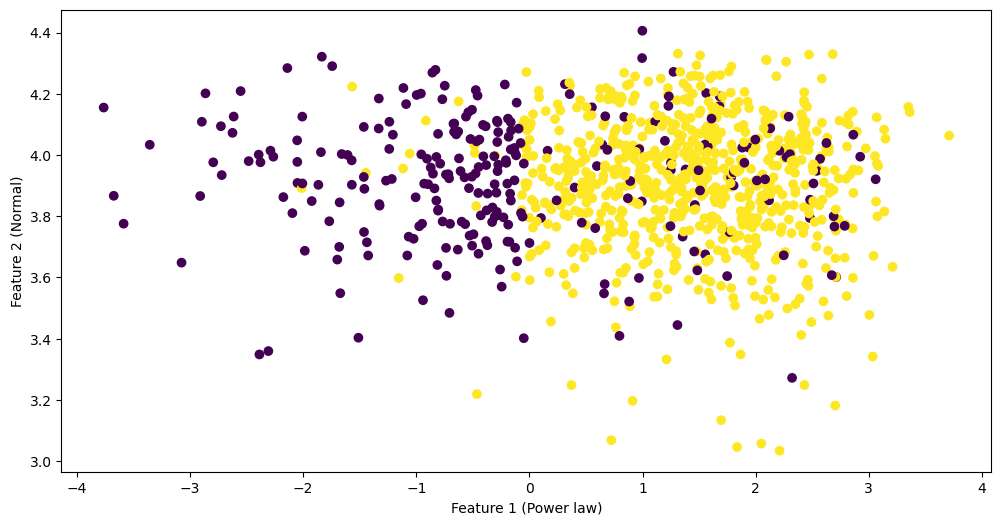

In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
import matplotlib.pyplot as plt

def runLogistic_regression(X, y):
  # Split the dataset
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Logistic Regression without scaling
  lr = LogisticRegression(max_iter=1000)
  lr.fit(X_train, y_train)
  print(f"Logistic Regression Test Accuracy: {lr.score(X_test, y_test):.2f}")

  # Plot original features
  plt.figure(figsize=(12, 6))
  plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
  plt.xlabel('Feature 1 (Power law)')
  plt.ylabel('Feature 2 (Normal)')
  plt.show()


# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic dataset
n_samples = 1000

# Feature 1: Power law (exponential) distribution
X1 = np.random.exponential(scale=5, size=n_samples)

# Feature 2: Normal distribution
X2 = np.random.normal(loc=50, scale=10, size=n_samples)

# Create labels: simple linear relation to X1 and X2
y = np.array([1 if x1 + 0.001 * x2 > 1 else 0 for x1, x2 in zip(X1, X2)])
flip_indices = np.random.choice(n_samples, size=int(0.1 * n_samples), replace=False)
y[flip_indices] = 1 - y[flip_indices]

# Combine features into single data array
X = np.column_stack((X1, X2))


print('Original')
runLogistic_regression(X, y)

print('Standard Scalar')
standardScaler = StandardScaler()
X_Standard = standardScaler.fit_transform(X)
print(X_Standard)
runLogistic_regression(X_Standard, y)

print('Log Normalized')
X_Log = np.log(X)
print(X_Log)
runLogistic_regression(X_Log, y)

#### **Exercise 3**

The **Titanic dataset** contains the passenger list for all 1309 passengers on the Titanic, 809 who perished and 500 who survived. In this exercise, try using different methods for dealing with the nulls in the "age" column, and running the same classifier to predict survival for each the different methods (you might try a `DecisionTreeClassifier`, or a `LogisticRegression` classifier, or a `SGDClassifier`).  Which method gives the best result?  Why do you think that is?  Please only use the following columns for modeling: `pclass`, `sex`, `age`, `sibsp`, `parch`.  Be sure to try the following methods:

1. Fill forward, using `ffill` in Pandas
2. Use "mean" with `SimpleImputer`
3. Use "most_frequent" with `SimpleImputer`
4. Use a `KNNImputer` from sklearn

In [4]:
titanic = pd.read_csv('https://ist707.s3.us-east-2.amazonaws.com/data/titanic.csv')
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   str    
 2   sex       1309 non-null   str    
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   str    
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    str    
 9   embarked  1307 non-null   str    
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 164.7 KB


In [5]:
titanic.survived.value_counts()

survived
0    809
1    500
Name: count, dtype: int64

In [6]:
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

titanic['ffiled_age'] = titanic[['age']].ffill()
age_imputer_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
age_imputer_mf = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
age_knn_imputer = KNNImputer()

titanic['age_mean'] = age_imputer_mean.fit_transform(titanic[['age']])
titanic['age_mf'] = age_imputer_mf.fit_transform(titanic[['age']])
titanic['age_knn'] = age_knn_imputer.fit_transform(titanic[['age']])

# need to encode the sex variable to work with logistic regression
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
titanic['sex'] = ordinal_encoder.fit_transform(titanic['sex'].values.reshape(-1,1))

X1 = titanic[['ffiled_age', 'pclass', 'sex', 'sibsp', 'parch']]
X2 = titanic[['age_mf', 'pclass', 'sex', 'sibsp', 'parch']]
X3 = titanic[['age_mean', 'pclass', 'sex', 'sibsp', 'parch']]
X4 = titanic[['age_knn', 'pclass', 'sex', 'sibsp', 'parch']]
y = titanic['survived']

log_reg = LogisticRegression()

# Perform 5-fold cross-validation
scores1 = cross_val_score(log_reg, X1, y, cv=5)
scores2 = cross_val_score(log_reg, X2, y, cv=5)
scores3 = cross_val_score(log_reg, X3, y, cv=5)
scores4 = cross_val_score(log_reg, X4, y, cv=5)

# Print average accuracy
print("Fill forward average accuracy: {:.2f}%".format(scores1.mean() * 100))
print("Most frequent average accuracy: {:.2f}%".format(scores2.mean() * 100))
print("Mean average accuracy: {:.2f}%".format(scores3.mean() * 100))
print("KNN imputer average accuracy: {:.2f}%".format(scores4.mean() * 100))

NotImplementedError: <class 'pandas.arrays.ArrowStringArray'> does not support reshape as backed by a 1D pyarrow.ChunkedArray.

#### **Exercise 4**

Use the one-hot encoding method introduced in `03-demo-04-encoding.ipynb` for encoding multiple columns to one-hot encode the following data.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

sample = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'red', 'blue', 'green'],
    'target': ['apple', 'sky', 'grass', 'sky', 'moon', 'apple']
})

encoder = OneHotEncoder(sparse_output=False)
result = encoder.fit_transform(sample)
out = pd.DataFrame(result, columns=np.concatenate((encoder.categories_[0], encoder.categories_[1])))
out.head()